# Threshold Tools: Extreme Value Analysis

This notebook demonstrates how to use `climakitae` to evaluate the frequency of extreme weather events in downscaled climate model simulations. This type of analysis is often called "Extreme value analysis" or "1-in-X analysis".

`climakitae` uses the Annual Maxima/Minima Series (AMS) method for extreme value analysis. In the AMS method, the maximum (or minimum) variable value is obtained for each year. A statistical distribution is fitted to the values and then used to obtain return probabilities, values, or periods. This methodology is built-in to the `climakitae` `metric_calc` processor so that users can generate 1-in-X results with a single call to the `ClimateData` object. Many customizable settings are provided.

**Terms used in this notebook**:
- __Return probabilities__: The probability of a threshold being exceeded within a given period of time. 
    - For example, the maximum temperature at a location has a 10% chance of exceeding 105°F in any year.
- __Return values__: The threshold for a given exceedance probability. Also known as the return level.
    - For example, the return value of 105°F has a return probability of 10%.
- __Return periods__: In inverse of the return probability, interpreted as the average expected wait time between threshold exceedances. 
    - For example, if there is a 10% return probability of air temperature exceeding 105°F, the return period of that event is once every 10 years.

**Intended Application**: As a user, I want to learn how to:
- **<span style="color:#FF0000">Generate return probabilities, return values, and return periods for climate simulations with climakitae.</span>**
- **<span style="color:#FF0000">Visualize the spatial distribution of return value results across a region.</span>**
- **<span style="color:#FF0000">Compare return periods results between different global warming levels.</span>**

**Runtime**: With the default settings, this notebook takes approximately **5 minutes** to run from start to finish. Modifications to selections may increase the runtime.

**References**: The techniques in this notebook come from applications of extreme value theory to climate data. These texts provide further reading on the topic:  
Cooley, D., 2009: Extreme value analysis and the study of climate change. Climatic Change 97, 77–83. https://doi.org/10.1007/s10584-009-9627-x  
Coles, S., 2001: An Introduction to Statistical Modeling of Extreme Values. Springer, 208 pp.  
Wilks, D. S., 2011: Statistical Methods in the Atmospheric Sciences. Academic Press, 676 pp.  


In [1]:
import climakitae as ck
import xarray as xr
import matplotlib.pyplot as plt
from climakitae.util.colormap import read_ae_colormap

### Understand the available 1-in-X options

The examples in this notebook use the `metric_calc` processor available through the `climakitae` `ClimateData` object to run 1-in-X evaluations. The following arguments can be passed to `one_in_x` in the `metric_calc` processor:

| Argument | Options | Required? | Notes |
|---|---|---|---|
| `return_periods` | List of ints | Required (or `return_values`) | Return periods in years, e.g. `[10, 25, 50]` |
| `return_values` | List of floats | Required (or `return_periods`) | Threshold values, e.g. `[105]` |
| `extremes_type` | `"max"`, `"min"` | Optional | Default: `"max"` |
| `distribution` | `"gev"`, `"genpareto"`, `"gumbel"`, `"weibull"`, `"pearson3"`, `"gamma"` | Optional | Default: `"gev"` |
| `event_duration` | `(int, "day")` | Optional | Window for sub-daily events |
| `grouped_duration` | `(int, "day")` | Optional | Consecutive-day event window for multi-day extremes |
| `block_size` | int (years) | Optional | Default: `1` |
| `alpha` | float | Optional | Default: `UNSET` (does not generate confidence intervals); set the alpha for confidence intervals, e.g. `'alpha' = 0.05` for 95% confidence intervals  |
| `bootstrap_runs` | int | Optional | Default: `100`; the number of bootstrap samples taken to calculate confidence intervals |
| `goodness_of_fit_test` | bool | Optional | Default: `True`; runs Kolmogorov-Smirnov test and returns p-values |
| `variable_preprocessing` | dict | Optional | Default: `{}`; `"precipitation"` options are `"daily_aggregation"` (bool, aggregate hourly to daily timescale) and `"remove_trace"` (bool, recommended to remove spurious precipitation amounts). See Section 3 for an example with `remove_trace`. |
| `check_ess` | bool | Optional | Default: `True`; calculates the effective sample size and warns if it fall below recommended value. ClimateData verbosity must be >= 0 to see warning. |

Here are the full names of the available distributions:
- "gev": Generalized extreme value (GEV) distribution  
- "gumbel": Gumbel distribution  
- "weibull": Weibull distribution  
- "genpareto": Generalized Pareto distribution  
- "gamma": Gamma distribution  
- "pearson3": Pearson Type III distribution
  
If unsure about the correct distribution to choose, the [Generalized Extreme Value distribution](https://en.wikipedia.org/wiki/Generalized_extreme_value_distribution) ("gev") is a good starting point as it is commonly used with climate data and the AMS method (Coles 2001).

### Threshold Tools Example 1. Calculate return values: precipitation at a single location

In this example, we calculate 1-in-X return values for daily precipitation at a single station (KSAC) across two warming levels. Here we use the bias-corrected WRF simulations, but this analysis can also be applied to the LOCA2 simulations. LOCA2 will take longer to run because of the larger number of simulations in that dataset.

To display more data processing information (including the effective sample size check), increase the verbosity to 0 or larger. The effective sample size is a measure of the independence of different time blocks. Data with high temporal autocorrelation will have a lower effective sample size and may produce biased return variables.

In [2]:
# Initialize the interface
cd = ck.ClimateData(verbosity=-1)  # change verbosity here
return_periods = [10, 25, 50]

one_in_x_data = (
    cd.catalog("cadcat")
    .activity_id("WRF")
    .institution_id("UCLA")
    .table_id("day")
    .grid_label("d02")
    .variable_id("prec")
    .processes(
        {
            "warming_level": {"warming_levels": [0.8, 3.0]},
            "convert_units": "inches/d",
            "clip": "KSAC",
            "metric_calc": {
                "one_in_x": {
                    "return_periods": return_periods,
                    "extremes_type": "max",
                    "alpha": 0.05,  # Set significance level to include confidence limits (alpha = 0.05 means 95% confidence level)
                    # "bootstrap_runs": 50 # Uncomment to change the number of bootstrap runs unsed to generate confidence limits. Default 100
                    # "block_size": 1 # Uncomment to change the block size (increase the block size to increase the effective sample size)
                }
            },
        }
    )
    .get()
)


Your query selected models that do not have a-priori bias adjustment. 
These models have been removed from the returned query. 
To include them, please add the following processor to your query: 
ClimateData().processes('filter_unadjusted_models': 'no')


Incomplete warming level for WRF.UCLA.EC-Earth3-Veg.ssp370.day.d02.r1i1p1f1 at 0.8C. 
Skipping this warming level.
  warnings.warn(


Incomplete warming level for WRF.UCLA.EC-Earth3-Veg.ssp370.day.d02.r1i1p1f1 at 0.8C. 
Skipping this warming level.


Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
# Removing `EC-Earth3-Veg` because it has incomplete WL 0.8
sims = [s.item() for s in one_in_x_data.sim if "EC-Earth3-Veg" not in s.item()]
one_in_x_data = one_in_x_data.sel(sim=sims)

The p-value from the Kolmogorov-Smirnov (KS) test measures how well the chosen distribution fits the annual maxima series. At the 95% confidence level, we use a significance level (p-value) of 0.05 to determine if the distribution fit is acceptable. If the p-value is greater than 0.05, the distribution fit is acceptable. If the p-value is lower than 0.05, the distribution fit is not acceptable and may not be appropriate for the data -- try a different `distribution` option in that case.

This `p-value` significance level is different than the `alpha` value we set for the `metric_calc` processor. The KS test p-value indicates whether the selected extreme value distribution is a good fit for the annual maxima series. The `alpha` parameter sets the significance level for the confidence interval around the return value.

In [4]:
# Examining p-values across simulation, warming_level, and one_in_x combinations
one_in_x_data.to_dataframe()[["p_values"]]

p_values
sim                                            warming_level one_in_x          
WRF_UCLA_TaiESM1_ssp370_day_d02_r1i1p1f1       0.8           10        0.887097
                                                             25        0.887097
                                                             50        0.887097
                                               3.0           10        0.918394
                                                             25        0.918394
                                                             50        0.918394
WRF_UCLA_MIROC6_ssp370_day_d02_r1i1p1f1        0.8           10        0.708813
                                                             25        0.708813
                                                             50        0.708813
                                               3.0           10        0.908462
                                                             25        0.908462
                                                             50        0.908462
WRF_UCLA_EC-Earth3_ssp370_day_d02_r1i1p1f1     0.8           10        0.965006
                                                             25        0.965006
                                                             50        0.965006
                                               3.0           10        0.999904
                                                             25        0.999904
                                                             50        0.999904
WRF_UCLA_MPI-ESM1-2-HR_ssp370_day_d02_r3i1p1f1 0.8           10        0.749863
                                                             25        0.749863
                                                             50        0.749863
                                               3.0           10        0.627189
                                                             25        0.627189
                                                             50        0.627189

Once we've confirmed that the p-values look reasonable, we'll display the return values along with their 95% confidence limits. These confidence limits are the 2.5th and 97.5th percentiles of return values generated with the bootstrap resampling method.

In [5]:
one_in_x_data.to_dataframe()[
    ["return_values", "conf_int_lower_limit", "conf_int_upper_limit"]
].groupby(["warming_level", "one_in_x"]).mean()

return_values  conf_int_lower_limit  \
warming_level one_in_x                                        
0.8           10             3.590997              2.939416   
              25             4.409765              3.451088   
              50             5.076995              3.809179   
3.0           10             3.745338              3.005339   
              25             4.653200              3.334456   
              50             5.455290              3.560009   

                        conf_int_upper_limit  
warming_level one_in_x                        
0.8           10                    4.151122  
              25                    6.576941  
              50                    9.698899  
3.0           10                    4.600997  
              25                    7.046398  
              50                   10.445981

**Interpretation:** As expected, longer return periods correspond to higher return values, reflecting the fact that more severe events occur less frequently.
<br>

### Threshold Tools Example 2. Calculate return periods: temperature over a region

In this example, we used a time-based approach to find the return period for a specific temperature threshold (115°F for a 3-day heat wave) across San Bernardino County for simulation years 2040-2060.  We then display the results as a map. 

This example demonstrates how to use the `event_duration` and `grouped_duration` keywords together to compute return periods for multi-day events, in this case a three-day event based on daily maximum temperature. 

This example will not include confidence limits because the `alpha` parameter is not set. Skipping confidence intervals will substatianlly speed up this example, which examines a 2-D region instead of a single location timeseries. This is because the confidence limits are generated using the bootstrap method, which resamples each timeseries in the dataset many times and may be slow for large regions.

In [6]:
# Set the three-day heatwave temperature
tmax_3day = 115

# Reset the `ck` object to clear the previous catalog query and processes
cd.reset()

one_in_x_temp = (
    cd.catalog("cadcat")
    .activity_id("WRF")
    .experiment_id(["historical", "ssp370"])
    .institution_id("UCLA")
    .table_id("day")
    .grid_label("d02")
    .variable_id("t2max")
    .processes(
        {
            "time_slice": (2040, 2060),
            "convert_units": "degF",
            "clip": "San Bernardino County",
            "metric_calc": {
                "one_in_x": {
                    "return_values": [tmax_3day],
                    "extremes_type": "max",
                    "event_duration": (1, "day"),
                    "grouped_duration": (3, "day"),  # select consecutive 3-day events
                }
            },
        }
    )
    .get()
)


Your query selected models that do not have a-priori bias adjustment. 
These models have been removed from the returned query. 
To include them, please add the following processor to your query: 
ClimateData().processes('filter_unadjusted_models': 'no')



Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

  return_periods = 1.0 / return_prob



Next we take the median of the return period in the five simulations and to visualize the return periods.

Note: 
- **Larger return periods indicate less frequent events (i.e. a longer wait time between events).** These areas have a lighter color on the map.   
- **Areas with smaller return periods are more susceptible to 3-day heat waves at the selected temperature.** These are the darker colors on the map. Areas with a return period of 1 have a 100% probability of experiencing the event each year based on this analysis.

In [7]:
# Getting San Bernardino County boundary for plotting
sb_county = ck.new_core.CATALOG.boundaries.get_counties(name="San Bernardino County")

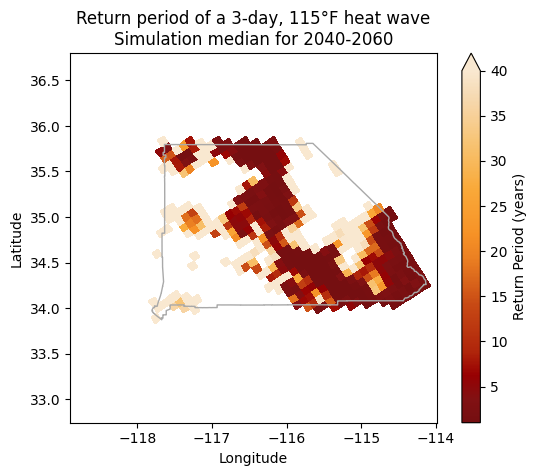

In [8]:
# Plotting the median return periods for a 3-day, 115°F heat wave across the county
fig, ax = plt.subplots()
one_in_x_temp["return_periods"].median("sim").sel(one_in_x=tmax_3day).plot(
    vmax=40,  # max color limit specific to the San Bernardino results
    vmin=1,
    cmap=read_ae_colormap("ae_orange").reversed(),
    x="lon",
    y="lat",
    ax=ax,
    cbar_kwargs={"label": "Return Period (years)"},
)
# Overlaying the county boundary
sb_county.boundary.plot(ax=ax, color="darkgrey", linewidth=1.0)
ax.set_title(
    f"Return period of a 3-day, {tmax_3day}°F heat wave\nSimulation median for 2040-2060"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

### Thresholds Tools Example 3. How Extreme Event Frequency Shifts Across Warming Levels

Another way to use these tools is to anchor on a **historically extreme precipitation threshold** and ask: *how much more frequently is this event to occur as the climate warms?*

Rather than using a single fixed threshold for all models, this example derives a **GCM-specific threshold** for each GCM: the 99.5th percentile of historical daily precipitation at KSAC. This percentile is computed only on wet days (precip > 1e-6 in/day) since we are primarily interested in the return period of these extreme precipitation events given precipitation occurs. The low 1e-6 in/day amount is used to remove spurious trace precipitation that occurs in some simulations. This model-specific extreme precipitation threshold is then used as the return value to estimate the model's return period at **WLs 0.8, 2.0, and 3.0**, and the results are finally combined across GCMs to get one return value per warming level.

In [9]:
# Using the same set of GCMs as `sims` in example 1
GCMS = ["EC-Earth3", "MPI-ESM1-2-HR", "TaiESM1", "MIROC6"]

results = []

# Data retrieval and processing loop for each GCM
for gcm in GCMS:

    # Step 1: 99.5th percentile of historical max daily precip for this GCM
    hist = (
        cd.reset()
        .catalog("cadcat")
        .activity_id("WRF")
        .institution_id("UCLA")
        .table_id("day")
        .grid_label("d02")
        .source_id(gcm)
        .variable_id("prec")
        .processes(
            {
                "warming_level": {"warming_levels": [0.8]},
                "convert_units": "inches/d",
                "clip": "KSAC",
            }
        )
        .get()
    )

    # Finding the 99.5th percentile of non-zero precipitation values, since we're interested in
    # the return period of extreme precipitation events when precipitation does occur.
    threshold = float(hist.prec.where(hist.prec > 1e-6).quantile(0.995))
    print(f"\n{gcm}: Historical 99.5th percentile = {threshold:.3f} in/day\n")

    # Step 2: return period for that GCM-specific threshold across warming levels
    rp = (
        cd.reset()
        .catalog("cadcat")
        .activity_id("WRF")
        .institution_id("UCLA")
        .table_id("day")
        .grid_label("d02")
        .source_id(gcm)
        .variable_id("prec")
        .processes(
            {
                "warming_level": {"warming_levels": [2.0, 3.0]},
                "convert_units": "inches/d",
                "clip": "KSAC",
                "metric_calc": {
                    "one_in_x": {
                        "return_values": [threshold],
                        "extremes_type": "max",
                        "variable_preprocessing": {
                            "precipitation": {"remove_trace": True}
                        },
                    }
                },
            }
        )
        .get()
    )
    results.append(rp.sel(one_in_x=threshold, drop=True))

return_period_data = xr.concat(results, dim="sim")


EC-Earth3: Historical 99.5th percentile = 2.224 in/day



Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]


MPI-ESM1-2-HR: Historical 99.5th percentile = 2.330 in/day



Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]


TaiESM1: Historical 99.5th percentile = 2.542 in/day



Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]


MIROC6: Historical 99.5th percentile = 2.300 in/day



Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]

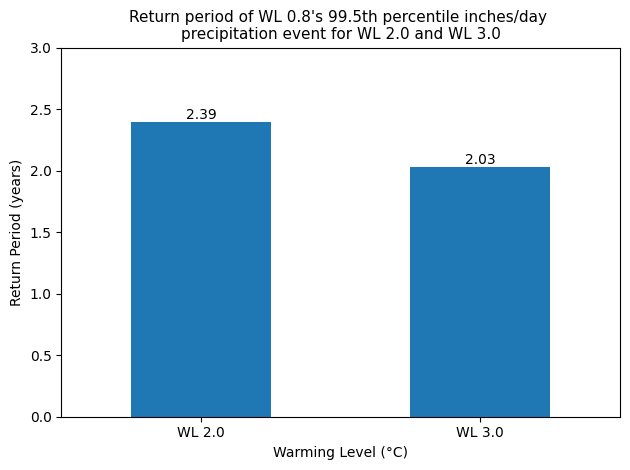

In [10]:
# Plotting the return period for the same return value across WL 0.8 and 2.0
rp_summary = (
    return_period_data.to_dataframe()[["return_periods"]]
    .groupby("warming_level")
    .median()
)

fig, ax = plt.subplots()
rp_summary["return_periods"].plot(kind="bar", ax=ax)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_xlabel("Warming Level (°C)")
ax.set_ylabel("Return Period (years)")
ax.set_title(
    f"Return period of WL 0.8's 99.5th percentile inches/day \nprecipitation event for WL 2.0 and WL 3.0",
    fontsize=11,
)
ax.set_xticks(range(len(rp_summary)))
ax.set_xticklabels([f"WL {wl}" for wl in rp_summary.index], rotation=0)
ax.set_ylim(0, 3)
plt.tight_layout()
plt.show()

**Conclusion:** As the warming levels increase from 0.8°C to 2.0°C, the median return period across GCMs decreases from **2.39 years** to **2.03 years**. This means that an historically extreme precipitation event becomes even more frequent under higher levels of global warming.

### Other Thresholds Tools Resources: Vulnerability Assessment
Now that you've seen how the different `1-in-X` calculations can be performed using `climakitae`, here is another notebook that uses similar functionality for vulnerability assessment purposes:

- **[Vulnerability Assessment](vulnerability_assessment.ipynb)**: Pre-built metric tables for IOU utility planning. Uses `cava_data()` to generate standardized 1-in-X outputs, percentiles,  across multiple variables.
